Paso 1: Generación del Dataset V2 (Más grande)
Este script crea una carpeta nueva Dataset_V2 con 500 imágenes (en lugar de 80).

Nombre del archivo sugerido: 1_preparar_dataset_v2.py

In [1]:
import os
import shutil
import random
from tqdm import tqdm

def preparar_dataset_v3(img_dir, shp_dir, output_dir, sample_size=600, seed=77):
    """
    Genera Dataset V3 con 600 imágenes.
    Seed 77 para variar respecto a la V2.
    """
    print(f"Configurando semilla aleatoria: {seed}")
    random.seed(seed)
    
    if not os.path.exists(img_dir) or not os.path.exists(shp_dir):
        print("ERROR: Revisa las rutas de entrada.")
        return

    print("Escaneando archivos...")
    tif_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith('.tif')])
    all_shp_files = os.listdir(shp_dir)
    shp_candidates = [f for f in all_shp_files if f.lower().endswith('.shp')]

    valid_pairs = []
    print("Buscando parejas...")
    for tif in tqdm(tif_files):
        base_name = os.path.splitext(tif)[0]
        match = next((s for s in shp_candidates if s.startswith(base_name)), None)
        if match:
            valid_pairs.append((tif, match))

    print(f"Total de pares encontrados: {len(valid_pairs)}")

    real_sample_size = min(sample_size, len(valid_pairs))
    print(f"Seleccionando {real_sample_size} imágenes para el Dataset V3...")
    
    selected_pairs = random.sample(valid_pairs, real_sample_size)
    random.shuffle(selected_pairs)
    
    # Split 80/20
    split_idx = int(len(selected_pairs) * 0.8)
    splits = {'train': selected_pairs[:split_idx], 'val': selected_pairs[split_idx:]}

    if os.path.exists(output_dir):
        print(f"Limpiando carpeta anterior: {output_dir}")
        shutil.rmtree(output_dir)
    
    for split_name, pairs in splits.items():
        dest_folder = os.path.join(output_dir, split_name)
        os.makedirs(dest_folder, exist_ok=True)
        
        print(f"Generando {split_name} ({len(pairs)} imgs)...")
        for tif_name, shp_name in tqdm(pairs):
            shutil.copy2(os.path.join(img_dir, tif_name), os.path.join(dest_folder, tif_name))
            shp_base = os.path.splitext(shp_name)[0]
            for f in all_shp_files:
                if f.startswith(shp_base):
                    shutil.copy2(os.path.join(shp_dir, f), os.path.join(dest_folder, f))

    print(f"\nDATASET V3 LISTO EN: {output_dir}")

if __name__ == "__main__":
    RUTA_IMAGENES = r"D:\Silos\Base de datos\procesado_sin_nubes\tiles"
    RUTA_SHAPES   = r"D:\Silos\Base de datos\procesado_sin_nubes\tiles\indices_INBNV\masks\polygons"
    RUTA_SALIDA_V3 = r"D:\Silos\Dataset_V3" 
    
    preparar_dataset_v3(RUTA_IMAGENES, RUTA_SHAPES, RUTA_SALIDA_V3, sample_size=600, seed=77)

Configurando semilla aleatoria: 77
Escaneando archivos...
Buscando parejas...


100%|██████████| 25749/25749 [00:34<00:00, 741.24it/s] 


Total de pares encontrados: 25749
Seleccionando 600 imágenes para el Dataset V3...
Generando train (480 imgs)...


100%|██████████| 480/480 [05:15<00:00,  1.52it/s]


Generando val (120 imgs)...


100%|██████████| 120/120 [01:26<00:00,  1.39it/s]


DATASET V3 LISTO EN: D:\Silos\Dataset_V3


Paso 2: Entrenamiento V2 (Optimizado)
Este script incluye Data Augmentation (rotación horizontal) y Anchor Boxes alargadas. Nota de tiempo: Al ser 500 imágenes en CPU, esto tardará unas cuantas horas (probablemente toda la noche). Lo configuré en 5 épocas, que debería ser suficiente para ver mejoras notables sin tardar días.

In [2]:
import os
import torch
import rasterio
import geopandas as gpd
import numpy as np
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models import ResNet50_Weights
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T # Necesario para el color jitter
from tqdm import tqdm
import time
import random

# --- CLASE DATASET CON AUGMENTATION AVANZADO ---
class SiloDatasetV3(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.imgs = [f for f in os.listdir(root_dir) if f.endswith('.tif')]
        
        # Transformación de color (solo afecta al tensor, no a las cajas)
        # Variamos brillo y contraste un 20%
        self.color_jitter = T.ColorJitter(brightness=0.2, contrast=0.2)

    def __getitem__(self, idx):
        img_filename = self.imgs[idx]
        img_path = os.path.join(self.root_dir, img_filename)
        
        base_name = os.path.splitext(img_filename)[0]
        files_in_dir = os.listdir(self.root_dir)
        shp_name = next((f for f in files_in_dir if f.startswith(base_name) and f.endswith('.shp')), None)
        shp_path = os.path.join(self.root_dir, shp_name) if shp_name else None

        # 1. Leer Imagen
        with rasterio.open(img_path) as src:
            try: img_data = src.read([1, 2, 3]) 
            except: img_data = src.read()[:3, :, :]
            transform = src.transform
            height, width = src.height, src.width
            
        # 2. Preprocesamiento
        img_data = np.nan_to_num(img_data.astype(np.float32), nan=0.0)
        max_val = np.max(img_data)
        if max_val > 255.0: img_data /= 10000.0
        elif max_val > 1.0: img_data /= 255.0
        img_data = np.clip(img_data, 0, 1)
        
        # --- AUGMENTATION GEOMÉTRICO (Numpy) ---
        # Definimos banderas para saber qué ajustar en las cajas luego
        do_hflip = random.random() > 0.5
        do_vflip = random.random() > 0.5

        if do_hflip:
            # Flip Eje 2 (Width)
            img_data = np.flip(img_data, axis=2).copy()
        
        if do_vflip:
            # Flip Eje 1 (Height)
            img_data = np.flip(img_data, axis=1).copy()

        img_tensor = torch.as_tensor(img_data, dtype=torch.float32)
        
        # --- AUGMENTATION RADIOMÉTRICO (Tensor) ---
        # Aplicamos cambios de luz al tensor
        img_tensor = self.color_jitter(img_tensor)

        # 3. Procesar Boxes
        boxes = []
        if shp_path and os.path.exists(shp_path):
            try:
                gdf = gpd.read_file(shp_path)
                if not gdf.empty:
                    for geom in gdf.geometry:
                        if geom.geom_type == 'Polygon':
                            xs, ys = zip(*geom.exterior.coords)
                            rows, cols = rasterio.transform.rowcol(transform, xs, ys)
                            
                            xmin, xmax = min(cols), max(cols)
                            ymin, ymax = min(rows), max(rows)
                            
                            # AJUSTAR CAJAS SEGÚN FLIPS
                            if do_hflip:
                                new_xmin = width - xmax
                                new_xmax = width - xmin
                                xmin, xmax = new_xmin, new_xmax
                            
                            if do_vflip:
                                new_ymin = height - ymax
                                new_ymax = height - ymin
                                ymin, ymax = new_ymin, new_ymax

                            xmin, ymin = max(0, xmin), max(0, ymin)
                            xmax, ymax = min(width, xmax), min(height, ymax)
                            
                            if (xmax - xmin) > 2 and (ymax - ymin) > 2:
                                boxes.append([xmin, ymin, xmax, ymax])
            except: pass

        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.ones((len(boxes),), dtype=torch.int64)
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
            iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([idx]), "area": area, "iscrowd": iscrowd}
        return img_tensor, target

    def __len__(self): return len(self.imgs)
    @staticmethod
    def collate_fn(batch): return tuple(zip(*batch))

# --- MODELO V3 (Misma Arquitectura V2) ---
def get_model_v3(num_classes):
    anchor_sizes = ((16,), (32,), (64,), (128,), (256,))
    aspect_ratios = ((0.2, 0.5, 1.0, 2.0, 5.0),) * len(anchor_sizes)
    
    anchor_generator = AnchorGenerator(sizes=anchor_sizes, aspect_ratios=aspect_ratios)
    
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=None, 
        weights_backbone=ResNet50_Weights.DEFAULT,
        rpn_anchor_generator=anchor_generator
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    total_loss = 0
    prog_bar = tqdm(data_loader, desc=f"Epoch {epoch}")
    
    for images, targets in prog_bar:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        if not torch.isnan(losses):
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            total_loss += losses.item()
            prog_bar.set_postfix(loss=losses.item())

    avg_loss = total_loss / len(data_loader)
    print(f"Epoch {epoch} Final Loss: {avg_loss:.4f}")
    return avg_loss

def main_v3():
    train_dir = r"D:\Silos\Dataset_V3\train"
    model_save_path = r"D:\Silos\modelo_silos_v3_aug.pth"
    
    device = torch.device('cpu')
    print(f"Iniciando entrenamiento V3 (Full Augmentation) en: {device}")

    dataset = SiloDatasetV3(train_dir)
    data_loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=SiloDatasetV3.collate_fn)

    model = get_model_v3(num_classes=2)
    model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.002, momentum=0.9, weight_decay=0.0005)

    num_epochs = 5
    start_time = time.time()
    
    for epoch in range(num_epochs):
        train_one_epoch(model, optimizer, data_loader, device, epoch)
    
    total_time = (time.time() - start_time) / 3600
    print(f"Entrenamiento V3 finalizado en {total_time:.2f} horas")

    torch.save(model.state_dict(), model_save_path)
    print(f"Modelo V3 guardado en: {model_save_path}")

if __name__ == "__main__":
    main_v3()

Iniciando entrenamiento V3 (Full Augmentation) en: cpu


Epoch 0: 100%|██████████| 240/240 [1:35:15<00:00, 23.81s/it, loss=0.797]


Epoch 0 Final Loss: 1.0726


Epoch 1: 100%|██████████| 240/240 [1:35:14<00:00, 23.81s/it, loss=1.1]  


Epoch 1 Final Loss: 1.0160


...

Epoch 2 Final Loss: 0.9794


Epoch 3: 100%|██████████| 240/240 [1:35:18<00:00, 23.83s/it, loss=1.1]  


Epoch 3 Final Loss: 0.9612


Epoch 4: 100%|██████████| 240/240 [1:35:53<00:00, 23.97s/it, loss=1.09] 


Epoch 4 Final Loss: 0.9459
Entrenamiento V3 finalizado en 7.95 horas
Modelo V3 guardado en: D:\Silos\modelo_silos_v3_aug.pth


Paso 3: Prueba / Inferencia V2
IMPORTANTE: No puedes usar el script de prueba anterior con el modelo nuevo. ¿Por qué? Porque el modelo nuevo tiene una estructura interna diferente (los Anchor Boxes). Si intentas cargar el modelo V2 en el script V1, te dará un error de "Key mismatch".

Usa este script para probar el V2:

Cargando modelo V3...
Visualizando 5 imágenes V3:


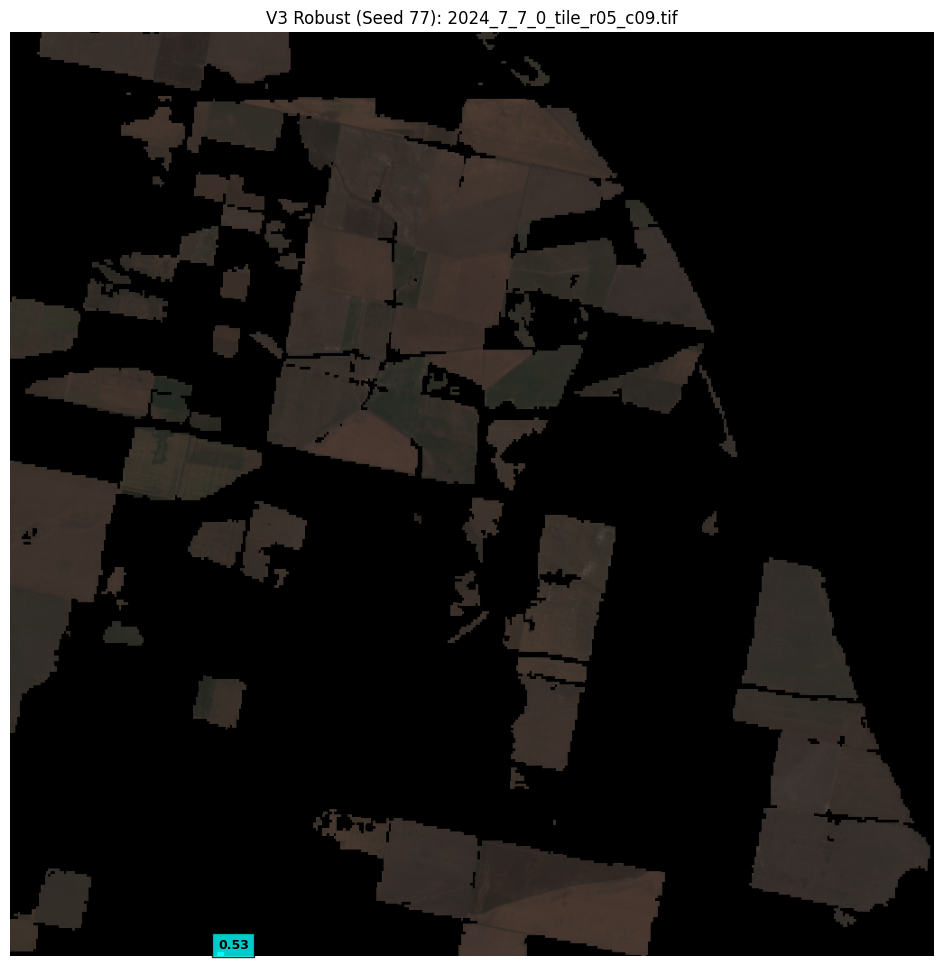

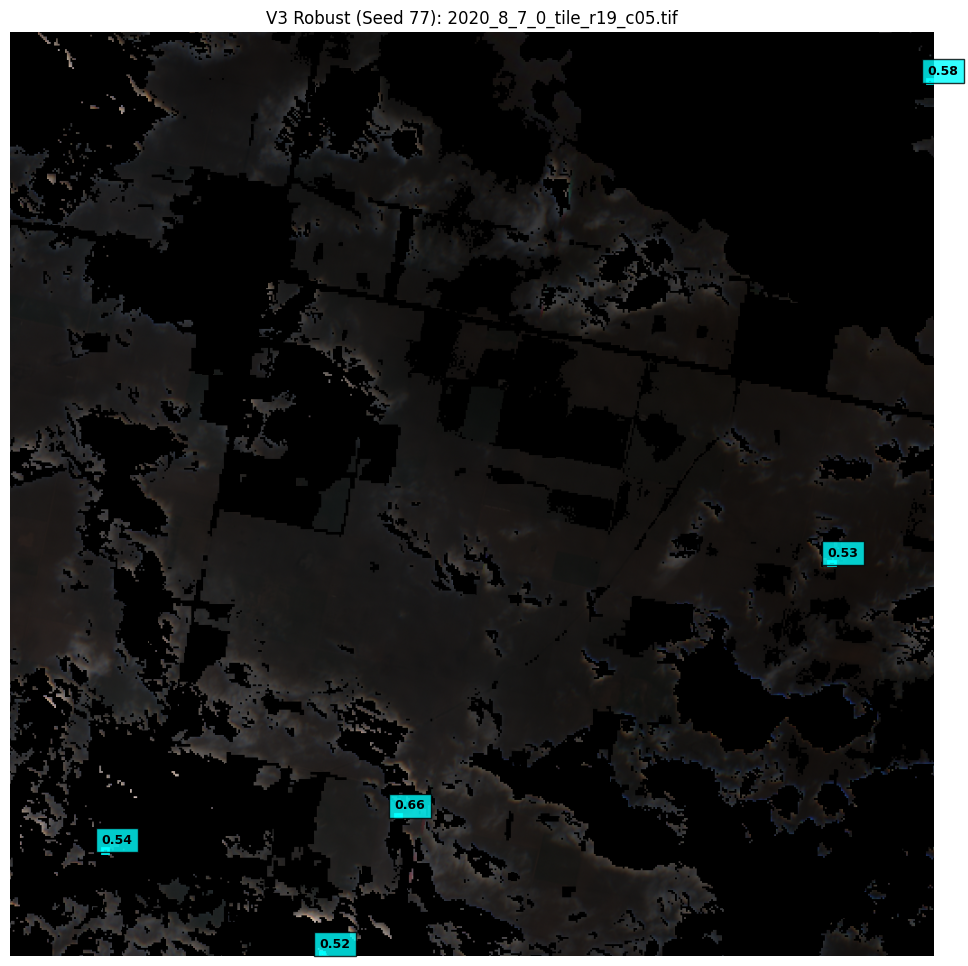

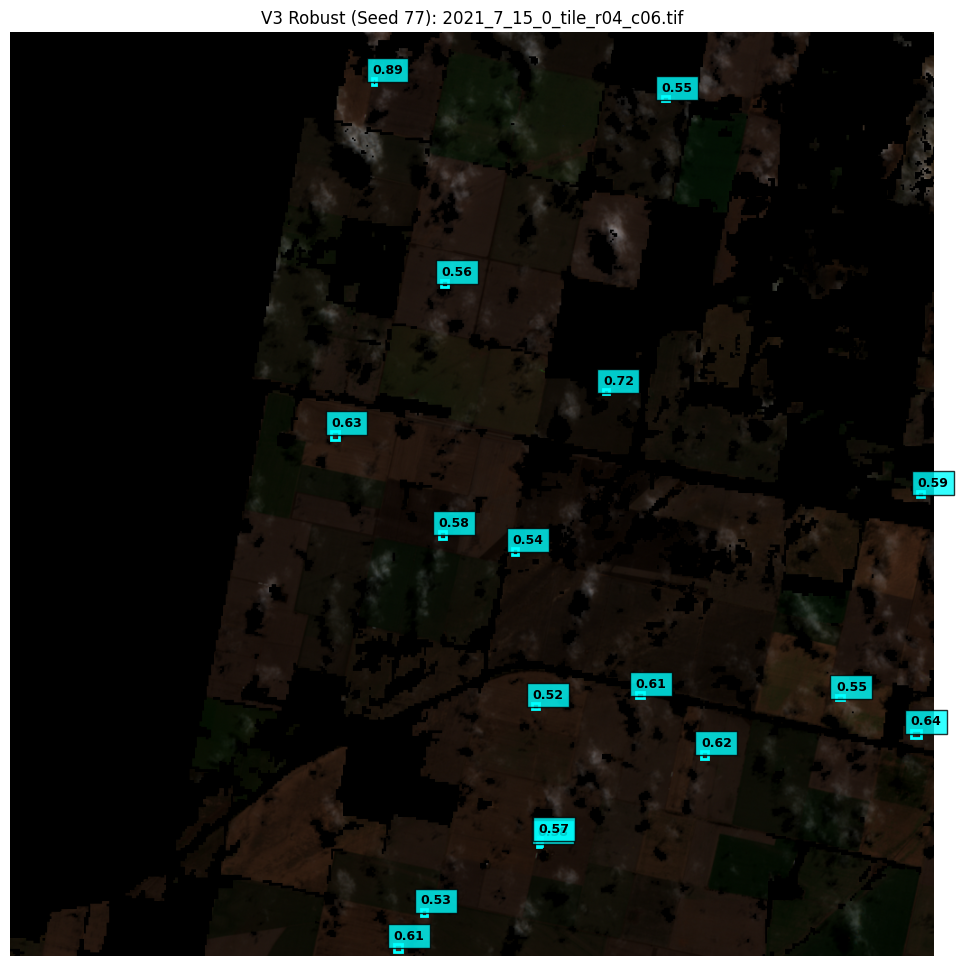

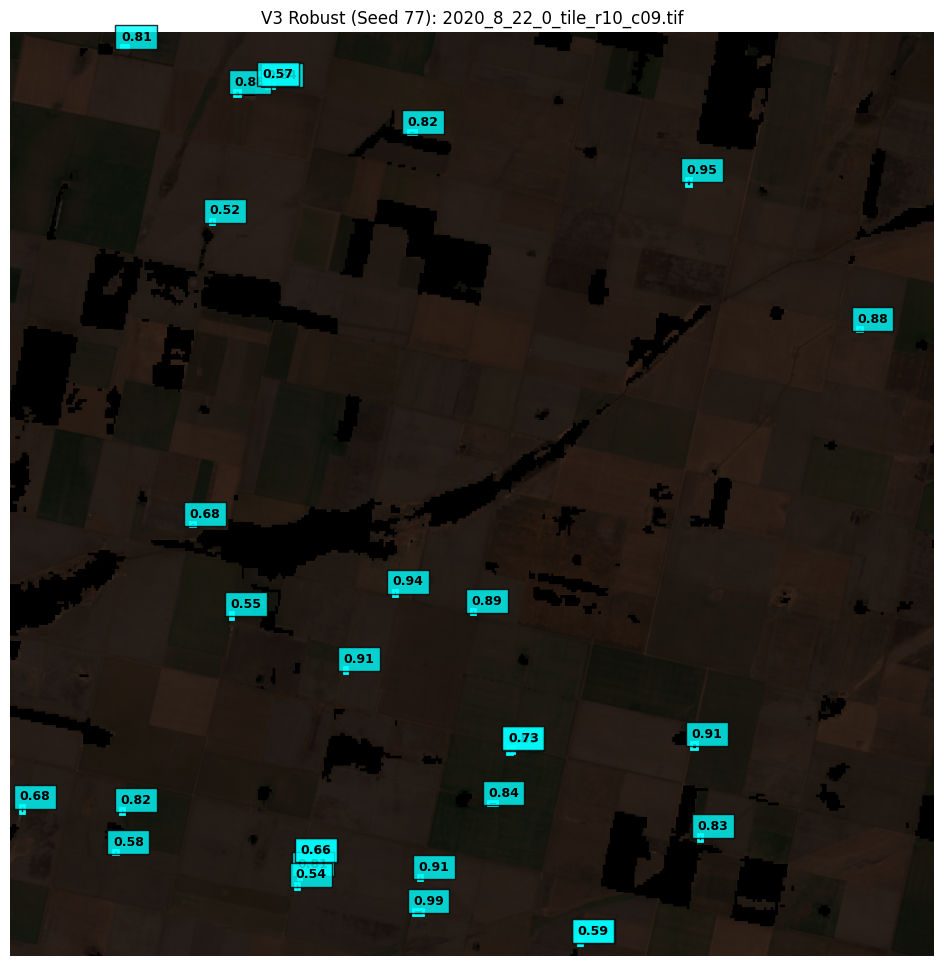

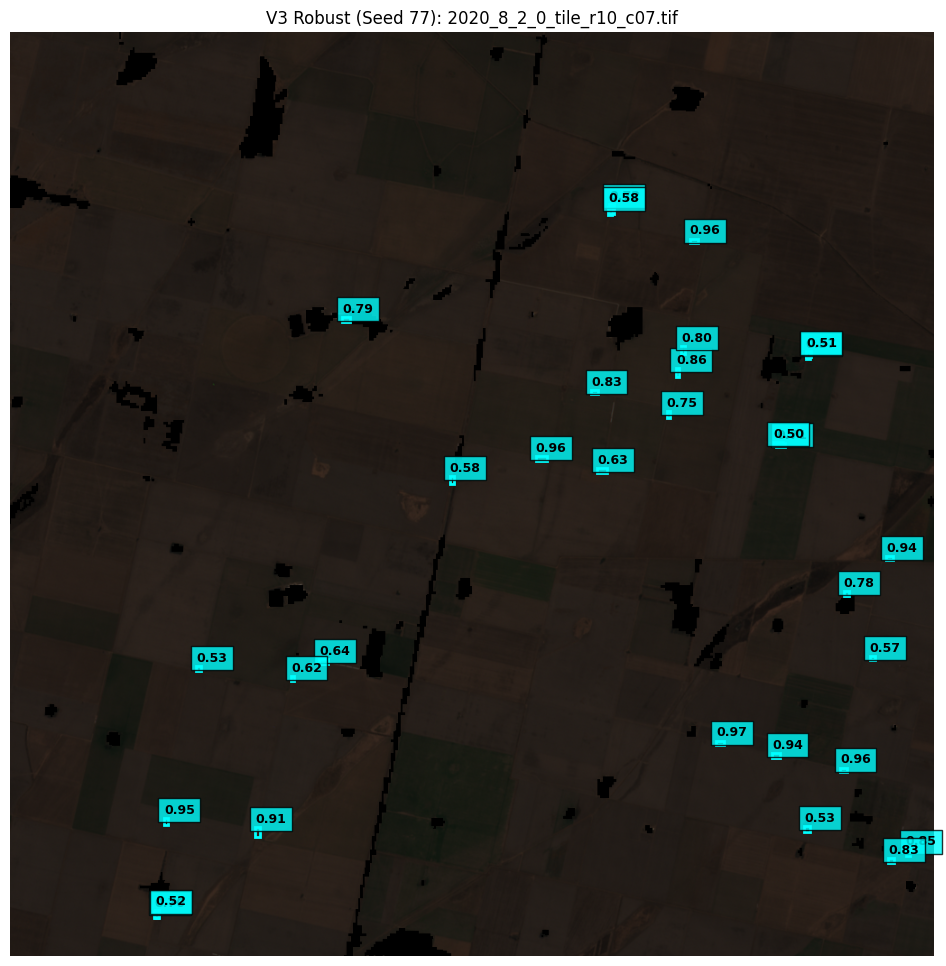

In [3]:
import os
import torch
import torchvision
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models import ResNet50_Weights
import random

# --- CONFIGURACIÓN V3 ---
MODEL_PATH = r"D:\Silos\modelo_silos_v3_aug.pth"
VAL_DIR = r"D:\Silos\Dataset_V3\val"
THRESHOLD = 0.5
SEED = 77 # Misma semilla que usaste para crear el dataset V3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_model_v3_inference(num_classes):
    anchor_sizes = ((16,), (32,), (64,), (128,), (256,))
    aspect_ratios = ((0.2, 0.5, 1.0, 2.0, 5.0),) * len(anchor_sizes)
    anchor_generator = AnchorGenerator(sizes=anchor_sizes, aspect_ratios=aspect_ratios)
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=None,
        weights_backbone=ResNet50_Weights.DEFAULT,
        rpn_anchor_generator=anchor_generator
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def preprocess_image(img_path):
    with rasterio.open(img_path) as src:
        try: img_data = src.read([1, 2, 3])
        except: img_data = src.read()[:3, :, :]
    img_data = np.nan_to_num(img_data.astype(np.float32), nan=0.0)
    max_val = np.max(img_data)
    if max_val > 255.0: img_data /= 10000.0
    elif max_val > 1.0: img_data /= 255.0
    img_data = np.clip(img_data, 0, 1)
    return torch.as_tensor(img_data, dtype=torch.float32)

def plot_prediction(img_tensor, prediction, threshold=0.5, filename=""):
    img_numpy = img_tensor.cpu().numpy().transpose(1, 2, 0)
    fig, ax = plt.subplots(1, figsize=(12, 12))
    ax.imshow(img_numpy)
    ax.set_title(f"V3 Robust (Seed {SEED}): {filename}")
    
    boxes = prediction[0]['boxes'].cpu().detach().numpy()
    scores = prediction[0]['scores'].cpu().detach().numpy()
    
    for box, score in zip(boxes, scores):
        if score >= threshold:
            xmin, ymin, xmax, ymax = box
            # Cyan para diferenciar de la V2
            rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, linewidth=2, edgecolor='cyan', facecolor='none')
            ax.add_patch(rect)
            ax.text(xmin, ymin-5, f'{score:.2f}', color='black', fontsize=9, weight='bold', bbox=dict(facecolor='cyan', alpha=0.8))
    
    plt.axis('off')
    plt.show()

def main_visual_v3():
    device = torch.device('cpu')
    if not os.path.exists(MODEL_PATH): return

    print(f"Cargando modelo V3...")
    model = get_model_v3_inference(num_classes=2)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()
    
    val_images = sorted([f for f in os.listdir(VAL_DIR) if f.endswith('.tif')])
    samples = random.sample(val_images, min(5, len(val_images)))
    
    print(f"Visualizando 5 imágenes V3:")
    for img_name in samples:
        img_path = os.path.join(VAL_DIR, img_name)
        img_tensor = preprocess_image(img_path)
        with torch.no_grad():
            prediction = model([img_tensor.to(device)])
        plot_prediction(img_tensor, prediction, THRESHOLD, img_name)

if __name__ == "__main__":
    main_visual_v3()

In [4]:
import os
import torch
import rasterio
import geopandas as gpd
from shapely.geometry import box
import numpy as np
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models import ResNet50_Weights
import random

# --- CONFIGURACIÓN V3 ---
MODEL_PATH = r"D:\Silos\modelo_silos_v3_aug.pth"
VAL_DIR = r"D:\Silos\Dataset_V3\val"
OUTPUT_DIR = r"D:\Silos\predicciones_individuales_v3"
THRESHOLD = 0.5
SEED = 77

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_model_v3_inference(num_classes):
    anchor_sizes = ((16,), (32,), (64,), (128,), (256,))
    aspect_ratios = ((0.2, 0.5, 1.0, 2.0, 5.0),) * len(anchor_sizes)
    anchor_generator = AnchorGenerator(sizes=anchor_sizes, aspect_ratios=aspect_ratios)
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=None,
        weights_backbone=ResNet50_Weights.DEFAULT,
        rpn_anchor_generator=anchor_generator
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def preprocess_image(img_path):
    with rasterio.open(img_path) as src:
        try: img_data = src.read([1, 2, 3])
        except: img_data = src.read()[:3, :, :]
    img_data = np.nan_to_num(img_data.astype(np.float32), nan=0.0)
    max_val = np.max(img_data)
    if max_val > 255.0: img_data /= 10000.0
    elif max_val > 1.0: img_data /= 255.0
    img_data = np.clip(img_data, 0, 1)
    return torch.as_tensor(img_data, dtype=torch.float32)

def main_export_v3():
    device = torch.device('cpu')
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    if not os.path.exists(MODEL_PATH): return

    model = get_model_v3_inference(num_classes=2)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()
    
    val_images = sorted([f for f in os.listdir(VAL_DIR) if f.endswith('.tif')])
    samples = random.sample(val_images, min(5, len(val_images)))
    
    print(f"Exportando 5 muestras V3 a {OUTPUT_DIR}...")

    for img_name in samples:
        img_path = os.path.join(VAL_DIR, img_name)
        img_tensor = preprocess_image(img_path)
        with torch.no_grad():
            prediction = model([img_tensor.to(device)])
        
        boxes_px = prediction[0]['boxes'].cpu().numpy()
        scores = prediction[0]['scores'].cpu().numpy()
        
        geometries = []
        valid_scores = []
        
        with rasterio.open(img_path) as src:
            transform = src.transform
            crs = src.crs
            for box_px, score in zip(boxes_px, scores):
                if score >= THRESHOLD:
                    xmin, ymin, xmax, ymax = box_px
                    x_min, y_max = rasterio.transform.xy(transform, ymin, xmin, offset='ul')
                    x_max, y_min = rasterio.transform.xy(transform, ymax, xmax, offset='ul')
                    geometries.append(box(x_min, y_min, x_max, y_max))
                    valid_scores.append(float(score))
        
        if len(geometries) > 0:
            output_name = f"pred_v3_{os.path.splitext(img_name)[0]}.shp"
            gdf = gpd.GeoDataFrame({'filename': img_name, 'score': valid_scores}, geometry=geometries, crs=crs)
            gdf.to_file(os.path.join(OUTPUT_DIR, output_name))
            print(f" [OK] {output_name}")
        else:
            print(f" [INFO] {img_name}: Sin detecciones.")

if __name__ == "__main__":
    main_export_v3()

Exportando 5 muestras V3 a D:\Silos\predicciones_individuales_v3...
 [OK] pred_v3_2024_7_7_0_tile_r05_c09.shp
 [OK] pred_v3_2020_8_7_0_tile_r19_c05.shp
 [OK] pred_v3_2021_7_15_0_tile_r04_c06.shp
 [OK] pred_v3_2020_8_22_0_tile_r10_c09.shp
 [OK] pred_v3_2020_8_2_0_tile_r10_c07.shp
